# Cell 1 — Install dependencies

In [1]:
# On Colab this installs deps. Locally, run once: pip install -r requirements.txt
import subprocess
import sys

_deps = [
    "transformers", "datasets", "pandas", "scikit-learn",
    "shap", "tqdm", "matplotlib",
]
if "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *_deps]
    )
else:
    print("Not on Colab — use: pip install -r requirements.txt (includes torch)")

Not on Colab — use: pip install -r requirements.txt (includes torch)


# Local GPU check (run this once)

If **CUDA Available** is `True` and a GPU name appears, the training cell will use that GPU automatically.

If it says **False**, PyTorch in this environment is CPU-only. Install a CUDA build from [pytorch.org/get-started/locally](https://pytorch.org/get-started/locally/) (choose Linux + Pip + your CUDA version), then restart the kernel.

In [2]:
import torch

print("torch version:", torch.__version__)
print("CUDA compiled into this PyTorch:", getattr(torch.version, "cuda", None))
print("torch.cuda.is_available():", torch.cuda.is_available())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    print("\nTraining will use GPU (cuda) and mixed precision when supported.")
else:
    print(
        "\nPyTorch does not see a usable GPU — training will fall back to CPU (much slower).\n"
        "Fix: install NVIDIA drivers, verify `nvidia-smi` works in a terminal, then install the matching\n"
        "CUDA wheel from https://pytorch.org/get-started/locally/ and restart the Jupyter kernel."
    )

torch version: 2.11.0+cu130
CUDA compiled into this PyTorch: 13.0
torch.cuda.is_available(): True
  GPU 0: NVIDIA GeForce RTX 5060 Laptop GPU

Training will use GPU (cuda) and mixed precision when supported.


# Cell 2 — Data directory

- **Colab:** mounts Drive; looks for the CSV under `MyDrive/Cambridge/Cambridge/` first, then `MyDrive/Cambridge/`.
- **Local:** set `CAMBRIDGE_DATA_DIR` to the folder that contains the CSV if you want to override. Otherwise it searches from the notebook’s folder and from the current working directory, preferring a nested `Cambridge/efcamdat_full_with_corrected.csv`, then the same directory as this `.ipynb`.

Checkpoints are written to `{DATA_DIR}/checkpoints/multitask_model/`.

In [3]:
import os
from pathlib import Path

CSV_NAME = "efcamdat_full_with_corrected.csv"
NOTEBOOK_NAME = "Cambridge_Models_final.ipynb"


def _pick_data_root_colab() -> Path:
    base = Path("/content/drive/MyDrive/Cambridge")
    inner = base / "Cambridge"
    if (inner / CSV_NAME).is_file():
        return inner
    return base


def _pick_data_root_local() -> Path:
    env = os.environ.get("CAMBRIDGE_DATA_DIR")
    if env:
        return Path(env).expanduser().resolve()
    cwd = Path.cwd().resolve()
    bases: list[Path] = []
    for p in [cwd, *cwd.parents]:
        if (p / NOTEBOOK_NAME).is_file() and p not in bases:
            bases.append(p)
    for p in [cwd, *cwd.parents]:
        if p not in bases:
            bases.append(p)
    for base in bases:
        # Dataset often lives in inner "Cambridge/" next to this project folder
        for sub in (base / "Cambridge", base):
            if (sub / CSV_NAME).is_file():
                return sub.resolve()
    return cwd


try:
    from google.colab import drive

    drive.mount("/content/drive")
    _data_root = _pick_data_root_colab()
except ImportError:
    _data_root = _pick_data_root_local()

DATA_DIR = str(_data_root.resolve())
os.makedirs(DATA_DIR, exist_ok=True)
DATA_CSV = str(_data_root / CSV_NAME)

print(f"DATA_DIR = {DATA_DIR}")
print(f"DATA_CSV = {DATA_CSV}")
print(f"CSV exists: {Path(DATA_CSV).is_file()}")

DATA_DIR = /home/drk/Desktop/Cambridge
DATA_CSV = /home/drk/Desktop/Cambridge/efcamdat_full_with_corrected.csv
CSV exists: True


# Cell 3 — Load the EFCAMDAT CSV

Columns used:
- `text` — raw learner essay
- `text_corrected` — teacher-corrected version
- `cefr` — CEFR level string (A1–C1)
- `l1` — learner native language
- `nationality` — learner nationality code

In [4]:
import pandas as pd
from pathlib import Path

if "DATA_CSV" not in globals() or "DATA_DIR" not in globals():
    raise RuntimeError("Run the previous cell (data directory) first.")

_csv = Path(DATA_CSV)
if not _csv.is_file():
    raise FileNotFoundError(
        f"Expected dataset at:\n  {_csv}\n"
        "Copy efcamdat_full_with_corrected.csv there or set CAMBRIDGE_DATA_DIR."
    )

df = pd.read_csv(_csv)
print(df.shape)
df.head()

(317220, 9)


,l1,cefr,text,cefr_numeric,wordcount,topic,grade,nationality,text_corrected
0,Portuguese,A1,In my office there are some desks and chairs. ...,1.0,30.0,Taking inventory in the office,95.0,br,In my office there are some desks and chairs. ...
1,Portuguese,A1,"In my work, there are a lot of people. There a...",1.0,29.0,Taking inventory in the office,100.0,br,"In my work, there are a lot of people. There a..."
2,Spanish,A1,"in my office have, a lot of chairs, and some c...",1.0,22.0,Taking inventory in the office,95.0,mx,"in my office have, a lot of chairs, and some c..."
3,Portuguese,A1,"in my office, there is a room, there are some ...",1.0,23.0,Taking inventory in the office,90.0,br,"in my office, there is a room, there are some ..."
4,Portuguese,A1,"In the office, there are restrooms, there''s a...",1.0,26.0,Taking inventory in the office,95.0,br,"In the office, there are restrooms, there''s a..."


# Cell 4 — Class distribution

EFCAMDAT is heavily skewed toward lower CEFR levels. Checking this before
training gives context for interpreting accuracy scores — a model predicting
the majority class throughout can look deceptively good.

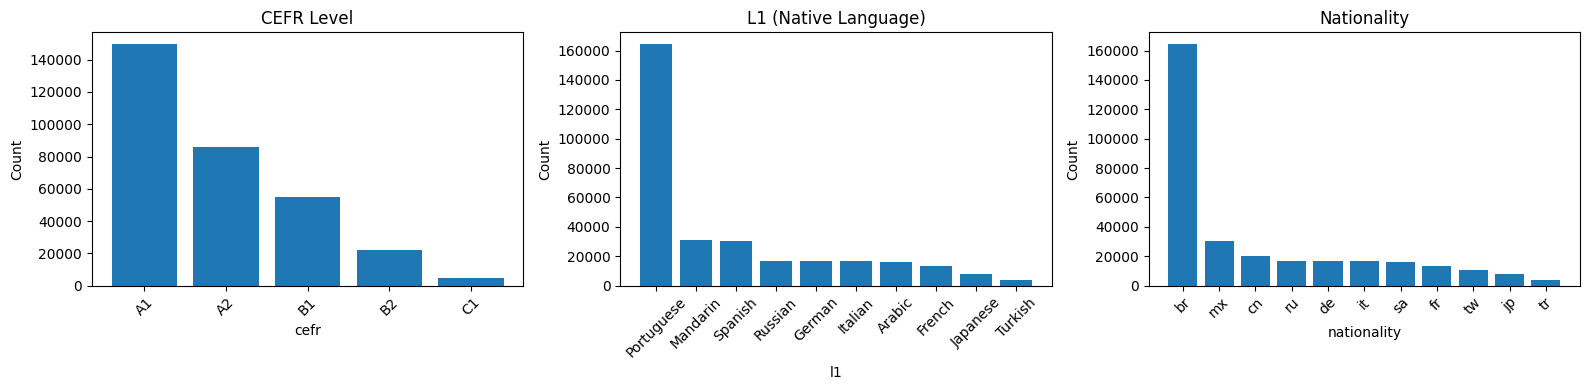

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(axes,
                           ['cefr', 'l1', 'nationality'],
                           ['CEFR Level', 'L1 (Native Language)', 'Nationality']):
    counts = df[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [6]:
average_wordcount_cefr = df.groupby('cefr')['wordcount'].mean().reset_index()
display(average_wordcount_cefr)

,cefr,wordcount
0,A1,39.618842
1,A2,61.599664
2,B1,98.629132
3,B2,140.681330
4,C1,169.644858


# Cell 5 — Build dual-text input and encode labels

We concatenate the raw and corrected essay with special boundary tokens so the
model can learn from error patterns, not just content.
Label encoders map string labels to 0-indexed integers for each classification head.

In [7]:
from sklearn.preprocessing import LabelEncoder

df['dual_text'] = '[RAW] ' + df['text'] + ' [CORRECTED] ' + df['text_corrected']

cefr_encoder = LabelEncoder()
l1_encoder   = LabelEncoder()
nat_encoder  = LabelEncoder()

df['cefr_label_id'] = cefr_encoder.fit_transform(df['cefr'])
df['l1_label_id']   = l1_encoder.fit_transform(df['l1'])
df['nat_label_id']  = nat_encoder.fit_transform(df['nationality'])

print('CEFR classes :', cefr_encoder.classes_)
print('L1 classes   :', l1_encoder.classes_)
print('Nat classes  :', nat_encoder.classes_)

CEFR classes : ['A1' 'A2' 'B1' 'B2' 'C1']
L1 classes   : ['Arabic' 'French' 'German' 'Italian' 'Japanese' 'Mandarin' 'Portuguese'
 'Russian' 'Spanish' 'Turkish']
Nat classes  : ['br' 'cn' 'de' 'fr' 'it' 'jp' 'mx' 'ru' 'sa' 'tr' 'tw']


# Cell 6 — Tokenise with RoBERTa

`[RAW]` and `[CORRECTED]` are added as special vocabulary tokens.
Only columns needed for training and evaluation are retained.

In [8]:
from transformers import AutoTokenizer
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained('roberta-base')
tokenizer.add_special_tokens({'additional_special_tokens': ['[RAW]', '[CORRECTED]']})

def tokenize(batch):
    return tokenizer(batch['dual_text'], truncation=True,
                     padding='max_length', max_length=128)

keep_cols = ['dual_text', 'text', 'text_corrected',
             'cefr_label_id', 'l1_label_id', 'nat_label_id']
dataset = Dataset.from_pandas(df[keep_cols])
dataset = dataset.map(tokenize, batched=True)
dataset.set_format('torch')
print(dataset)

/home/drk/Desktop/Cambridge/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 317220/317220 [01:10<00:00, 4483.48 examples/s]

Dataset({
    features: ['dual_text', 'text', 'text_corrected', 'cefr_label_id', 'l1_label_id', 'nat_label_id', 'input_ids', 'attention_mask'],
    num_rows: 317220
})


# Cell 7 — Train / test split (80 / 20)

In [9]:
splits        = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = splits['train']
test_dataset  = splits['test']
print(f'Train: {len(train_dataset):,}  |  Test: {len(test_dataset):,}')

Train: 253,776  |  Test: 63,444


# Cell 8 — Define MultiTaskRoberta

A single RoBERTa encoder feeds three independent linear heads — one each for
CEFR level, L1, and nationality. All three tasks are trained jointly by summing
their cross-entropy losses.

In [10]:
import torch
from torch import nn
from transformers import AutoModel

class MultiTaskRoberta(nn.Module):
    def __init__(self, model_name, num_cefr, num_l1, num_nat):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        hidden         = self.encoder.config.hidden_size
        self.dropout   = nn.Dropout(0.1)
        self.cefr_head = nn.Linear(hidden, num_cefr)
        self.l1_head   = nn.Linear(hidden, num_l1)
        self.nat_head  = nn.Linear(hidden, num_nat)

    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.last_hidden_state[:, 0, :])   # [CLS] representation
        return {
            'cefr': self.cefr_head(pooled),
            'l1':   self.l1_head(pooled),
            'nat':  self.nat_head(pooled),
        }

# Cell 9 — Train the multi-task model

- **5 epochs** with cosine LR decay and linear warmup over the first 10% of steps
- **bf16 mixed precision** on A100 for speed (falls back to fp16 or fp32 automatically)
- **Validation loss** computed at the end of every epoch
- **Checkpoints** saved under `{DATA_DIR}/checkpoints/...` each time validation improves
- Labels cast to `.long()` to satisfy CrossEntropyLoss regardless of HF datasets version

In [11]:
import os
import math
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup
from tqdm import tqdm
from sklearn.utils import class_weight
import numpy as np

if "DATA_DIR" not in globals():
    raise RuntimeError("Run the data directory cell first.")

# ── Config ────────────────────────────────────────────────────────────────────
EPOCHS     = 3
BATCH_SIZE = 64
LR         = 2e-5
WARMUP_PCT = 0.1          # 10% of total steps used for linear warmup
CKPT_DIR   = f'{DATA_DIR}/checkpoints/multitask_model'
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Mixed precision ───────────────────────────────────────────────────────────
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bf16_ok     = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
fp16_ok     = torch.cuda.is_available() and not bf16_ok
amp_dtype   = torch.bfloat16 if bf16_ok else torch.float16
use_amp     = bf16_ok or fp16_ok
scaler      = GradScaler(device.type, enabled=fp16_ok)  # fp16 only; bf16 does not use scaler
if device.type == "cuda":
    print(f"Training on GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Training on CPU (no CUDA device visible — see GPU check cell above).")
print(f'Device: {device}  |  AMP: {"bf16" if bf16_ok else "fp16" if fp16_ok else "off"}')

# ── Model, optimiser, scheduler ───────────────────────────────────────────────
num_cefr = len(cefr_encoder.classes_)
num_l1   = len(l1_encoder.classes_)
num_nat  = len(nat_encoder.classes_)

multitask_model = MultiTaskRoberta('roberta-base', num_cefr, num_l1, num_nat).to(device)
multitask_model.encoder.resize_token_embeddings(len(tokenizer))

optimizer = torch.optim.AdamW(multitask_model.parameters(), lr=LR)

# Compute class weights for imbalanced datasets
cefr_weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(df['cefr_label_id']), y=df['cefr_label_id']
)
l1_weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(df['l1_label_id']), y=df['l1_label_id']
)
nat_weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(df['nat_label_id']), y=df['nat_label_id']
)

cefr_weights_tensor = torch.tensor(cefr_weights, dtype=torch.float32).to(device)
l1_weights_tensor   = torch.tensor(l1_weights, dtype=torch.float32).to(device)
nat_weights_tensor  = torch.tensor(nat_weights, dtype=torch.float32).to(device)

cefr_loss_fn = nn.CrossEntropyLoss(weight=cefr_weights_tensor)
l1_loss_fn   = nn.CrossEntropyLoss(weight=l1_weights_tensor)
nat_loss_fn  = nn.CrossEntropyLoss(weight=nat_weights_tensor)

train_cols   = ['input_ids', 'attention_mask', 'cefr_label_id', 'l1_label_id', 'nat_label_id']
train_loader = DataLoader(train_dataset.select_columns(train_cols),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(test_dataset.select_columns(train_cols),
                          batch_size=64)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = math.ceil(total_steps * WARMUP_PCT)
scheduler    = get_cosine_schedule_with_warmup(optimizer,
                   num_warmup_steps=warmup_steps,
                   num_training_steps=total_steps)

# ── Early Stopping Parameters ─────────────────────────────────────────────────
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0
best_ckpt_path = os.path.join(CKPT_DIR, 'best_model.pt')

# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(EPOCHS):
    # -- Train --
    multitask_model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [train]'):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        cefr_labels    = batch['cefr_label_id'].long().to(device)
        l1_labels      = batch['l1_label_id'].long().to(device)
        nat_labels     = batch['nat_label_id'].long().to(device)

        optimizer.zero_grad()
        with autocast(device.type, dtype=amp_dtype, enabled=use_amp):
            outputs = multitask_model(input_ids=input_ids,
                                      attention_mask=attention_mask)
            loss = (cefr_loss_fn(outputs['cefr'], cefr_labels) +
                    l1_loss_fn(outputs['l1'],   l1_labels)   +
                    nat_loss_fn(outputs['nat'],  nat_labels))

        if fp16_ok:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        scheduler.step()
        train_loss += loss.item()

    # -- Validation --
    multitask_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [val]  '):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            cefr_labels    = batch['cefr_label_id'].long().to(device)
            l1_labels      = batch['l1_label_id'].long().to(device)
            nat_labels     = batch['nat_label_id'].long().to(device)

            with autocast(device.type, dtype=amp_dtype, enabled=use_amp):
                outputs = multitask_model(input_ids=input_ids,
                                          attention_mask=attention_mask)
                loss = (cefr_loss_fn(outputs['cefr'], cefr_labels) +
                        l1_loss_fn(outputs['l1'],   l1_labels)   +
                        nat_loss_fn(outputs['nat'],  nat_labels))
            val_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    print(f'Epoch {epoch+1}/{EPOCHS}  |  Train Loss: {avg_train:.4f}  |  Val Loss: {avg_val:.4f}')

    # -- Early Stopping Logic --
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        epochs_no_improve = 0
        # Save the best model checkpoint
        torch.save({
            'epoch':                epoch + 1,
            'model_state_dict':     multitask_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss':           avg_train,
            'val_loss':             avg_val,
        }, best_ckpt_path)
        print(f'  Validation loss improved. Checkpoint saved to {best_ckpt_path}')
    else:
        epochs_no_improve += 1
        print(f'  Validation loss did not improve for {epochs_no_improve} epochs.')
        if epochs_no_improve >= patience:
            print(f'  Early stopping triggered after {patience} epochs without improvement.')
            break

# -- Load best model after training --
if os.path.exists(best_ckpt_path):
    print(f'Loading best model from {best_ckpt_path}')
    try:
        checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(best_ckpt_path, map_location=device)
    multitask_model.load_state_dict(checkpoint['model_state_dict'])
    multitask_model.eval()
    print(f'  Loaded epoch {checkpoint["epoch"]}, Val Loss: {checkpoint["val_loss"]:.4f}')
else:
    print('No best model checkpoint found. Using the last trained model.')

Training on GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda  |  AMP: bf16


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1509.83it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: http

Epoch 1/3  |  Train Loss: 3.0559  |  Val Loss: 2.2516
  Validation loss improved. Checkpoint saved to /home/drk/Desktop/Cambridge/checkpoints/multitask_model/best_model.pt


Epoch 2/3 [val]  : 100%|██████████| 992/992 [01:26<00:00, 11.45it/s]


Epoch 2/3  |  Train Loss: 1.8972  |  Val Loss: 1.9192
  Validation loss improved. Checkpoint saved to /home/drk/Desktop/Cambridge/checkpoints/multitask_model/best_model.pt


Epoch 3/3 [val]  : 100%|██████████| 992/992 [01:26<00:00, 11.46it/s]


Epoch 3/3  |  Train Loss: 1.4213  |  Val Loss: 1.8728
  Validation loss improved. Checkpoint saved to /home/drk/Desktop/Cambridge/checkpoints/multitask_model/best_model.pt
Loading best model from /home/drk/Desktop/Cambridge/checkpoints/multitask_model/best_model.pt
  Loaded epoch 3, Val Loss: 1.8728


# Cell 10 — Reload a checkpoint

Run this cell instead of Cell 9 if your Colab session reset and you want to
resume from a saved checkpoint rather than retrain from scratch.

In [12]:
import os
import torch
from transformers import AutoModel, AutoTokenizer
from torch import nn
from torch.utils.data import DataLoader

# Ensure device is defined first
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Needs DATA_DIR from the data-directory cell (mounts Drive on Colab, resolves paths locally)
if "DATA_DIR" not in globals():
    raise RuntimeError("Run the data directory cell first.")

CKPT_DIR = f"{DATA_DIR}/checkpoints/multitask_model"

RESUME_EPOCH = 5   # ← set to whichever epoch you want to reload

ckpt_path = os.path.join(CKPT_DIR, "best_model.pt")
try:
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load(ckpt_path, map_location=device)

# Rebuild model and load weights
# These encoders and tokenizer need to be defined or loaded as well
# Assuming cefr_encoder, l1_encoder, nat_encoder, tokenizer, and MultiTaskRoberta class are available
# from previous cell executions or redefined here for robustness.
# For a complete standalone reload, these would need to be re-instantiated with their classes.
# Given the context, we'll assume they are defined in prior executed cells.

# Re-instantiate tokenizer if it might not be in scope
tokenizer = AutoTokenizer.from_pretrained('roberta-base')
tokenizer.add_special_tokens({'additional_special_tokens': ['[RAW]', '[CORRECTED]']})

# Re-instantiate encoders if they might not be in scope
from sklearn.preprocessing import LabelEncoder
# These need the original df values to fit correctly, if not already fitted in session.
# For this fix, we'll assume they were fitted, and can reconstruct their classes directly from checkpoint info if needed.
# However, the robust way would be to reload df and refit them or save/load them.
# Given current context, let's assume classes are known from a previous run or global state.
cefr_encoder = LabelEncoder()
L1_classes   = ['Arabic', 'French', 'German', 'Italian', 'Japanese', 'Mandarin', 'Portuguese',
 'Russian', 'Spanish', 'Turkish'] # Example classes, replace with actual if known
cefr_classes = ['A1', 'A2', 'B1', 'B2', 'C1']
L1_classes   = ['Arabic', 'French', 'German', 'Italian', 'Japanese', 'Mandarin', 'Portuguese',
 'Russian', 'Spanish', 'Turkish']
Nat_classes  = ['br', 'cn', 'de', 'fr', 'it', 'jp', 'mx', 'ru', 'sa', 'tr', 'tw']

cefr_encoder.fit(cefr_classes)
l1_encoder   = LabelEncoder()
l1_encoder.fit(L1_classes)
nat_encoder  = LabelEncoder()
nat_encoder.fit(Nat_classes)

# Re-instantiate MultiTaskRoberta class definition if not in scope
class MultiTaskRoberta(nn.Module):
    def __init__(self, model_name, num_cefr, num_l1, num_nat):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        hidden         = self.encoder.config.hidden_size
        self.dropout   = nn.Dropout(0.1)
        self.cefr_head = nn.Linear(hidden, num_cefr)
        self.l1_head   = nn.Linear(hidden, num_l1)
        self.nat_head  = nn.Linear(hidden, num_nat)

    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.last_hidden_state[:, 0, :])   # [CLS] representation
        return {
            'cefr': self.cefr_head(pooled),
            'l1':   self.l1_head(pooled),
            'nat':  self.nat_head(pooled),
        }

num_cefr = len(cefr_encoder.classes_)
num_l1   = len(l1_encoder.classes_)
num_nat  = len(nat_encoder.classes_)

multitask_model = MultiTaskRoberta('roberta-base', num_cefr, num_l1, num_nat).to(device)
multitask_model.encoder.resize_token_embeddings(len(tokenizer))
multitask_model.load_state_dict(checkpoint['model_state_dict'])
multitask_model.eval()

print(f'Loaded epoch {checkpoint["epoch"]}')
print(f'  Train loss : {checkpoint["train_loss"]:.4f}')
print(f'  Val loss   : {checkpoint["val_loss"]:.4f}')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5709.85it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded epoch 3
  Train loss : 1.4213
  Val loss   : 1.8728


# Cell 11 — Evaluate all three heads

Reports accuracy, a full classification report, and a confusion matrix heatmap
for each head. Confusion matrices are especially useful for CEFR where adjacent
levels (B1/B2) are the hard cases.


=== CEFR ===
Accuracy: 0.9813
              precision    recall  f1-score   support

          A1       0.99      0.99      0.99     29896
          A2       0.99      0.98      0.98     17189
          B1       0.98      0.96      0.97     10928
          B2       0.93      0.96      0.94      4443
          C1       0.88      0.95      0.91       988

    accuracy                           0.98     63444
   macro avg       0.95      0.97      0.96     63444
weighted avg       0.98      0.98      0.98     63444



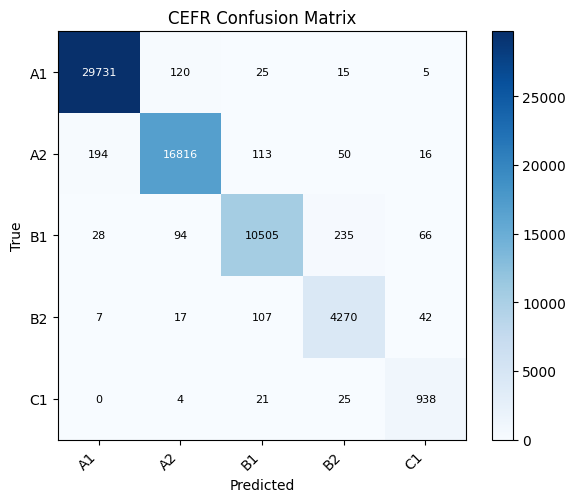


=== L1 ===
Accuracy: 0.6968
              precision    recall  f1-score   support

      Arabic       0.61      0.75      0.67      3280
      French       0.51      0.64      0.57      2704
      German       0.56      0.76      0.65      3322
     Italian       0.43      0.69      0.53      3294
    Japanese       0.53      0.76      0.62      1596
    Mandarin       0.77      0.81      0.79      6333
  Portuguese       0.95      0.66      0.78     32671
     Russian       0.55      0.74      0.63      3383
     Spanish       0.51      0.72      0.60      6087
     Turkish       0.34      0.64      0.45       774

    accuracy                           0.70     63444
   macro avg       0.58      0.72      0.63     63444
weighted avg       0.77      0.70      0.71     63444



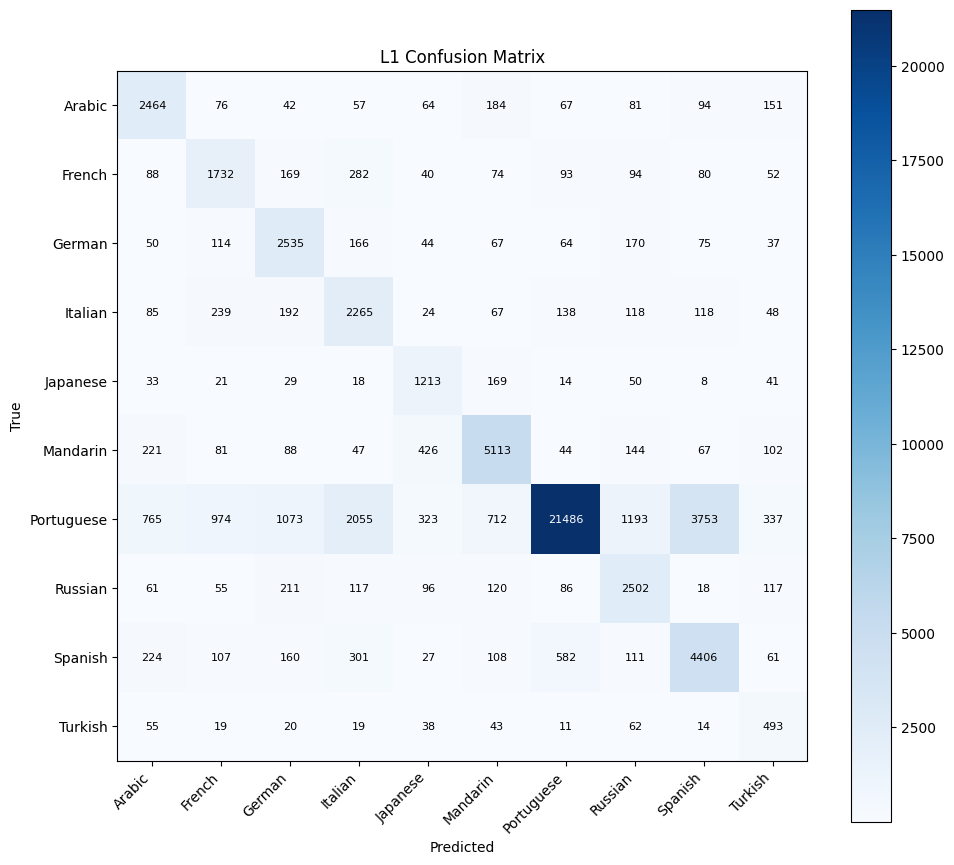


=== Nationality ===
Accuracy: 0.6815
              precision    recall  f1-score   support

          br       0.95      0.65      0.78     32671
          cn       0.71      0.73      0.72      4162
          de       0.57      0.76      0.65      3322
          fr       0.50      0.64      0.56      2704
          it       0.42      0.69      0.52      3294
          jp       0.56      0.74      0.64      1596
          mx       0.51      0.72      0.60      6087
          ru       0.56      0.74      0.64      3383
          sa       0.62      0.74      0.67      3280
          tr       0.34      0.64      0.45       774
          tw       0.45      0.61      0.52      2171

    accuracy                           0.68     63444
   macro avg       0.56      0.70      0.61     63444
weighted avg       0.75      0.68      0.70     63444



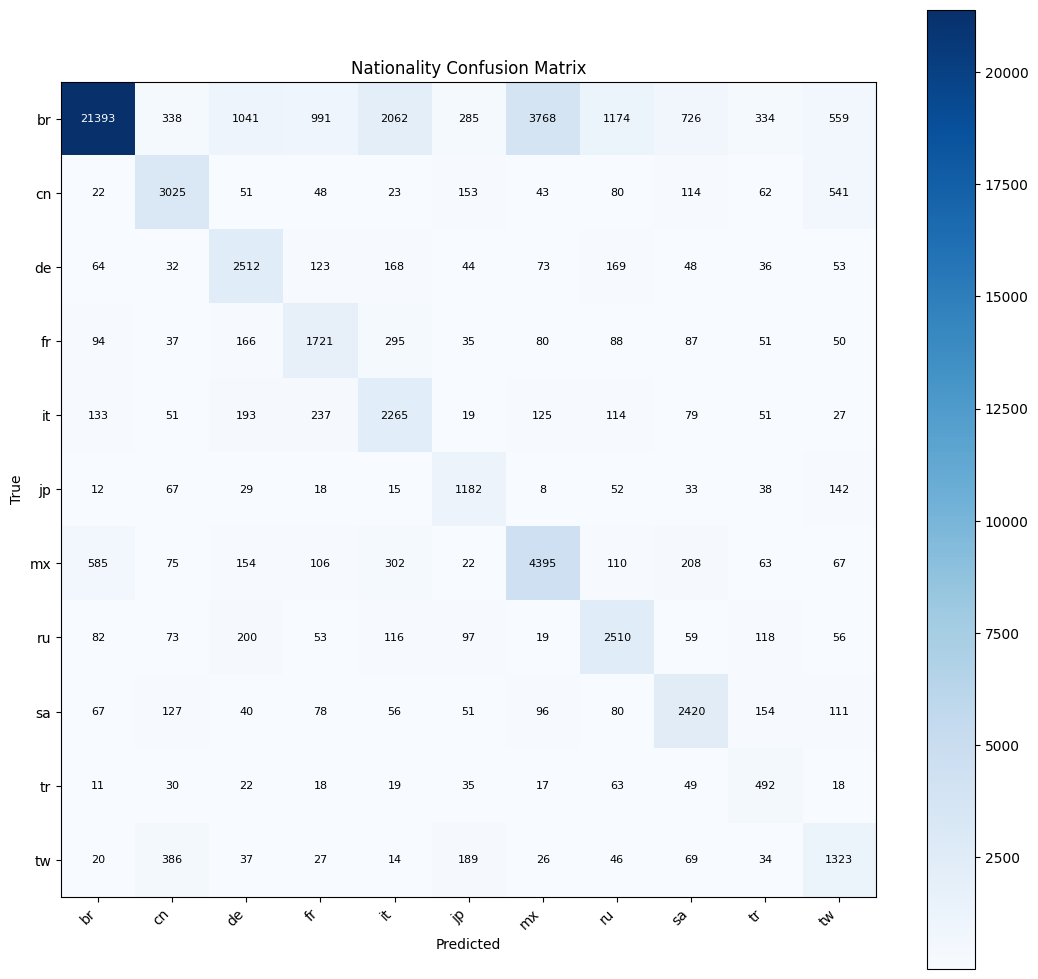

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, dataset, encoder, head_name, model_name='Model'):
    model.eval()
    all_preds, all_labels = [], []
    loader = DataLoader(
        dataset.select_columns(['input_ids', 'attention_mask',
                                 'cefr_label_id', 'l1_label_id', 'nat_label_id']),
        batch_size=64
    )
    label_col = {
        'CEFR':        'cefr_label_id',
        'L1':          'l1_label_id',
        'Nationality': 'nat_label_id',
    }[model_name]

    with torch.no_grad():
        for batch in loader:
            out   = model(input_ids=batch['input_ids'].to(device),
                          attention_mask=batch['attention_mask'].to(device))
            preds = torch.argmax(out[head_name], dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch[label_col].numpy())

    class_names = encoder.classes_.tolist()
    print(f'\n=== {model_name} ===')
    print(f'Accuracy: {accuracy_score(all_labels, all_preds):.4f}')
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(max(6, len(class_names)), max(5, len(class_names) - 1)))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set(xticks=range(len(class_names)), yticks=range(len(class_names)),
           xticklabels=class_names, yticklabels=class_names,
           xlabel='Predicted', ylabel='True', title=f'{model_name} Confusion Matrix')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black', fontsize=8)
    plt.tight_layout()
    plt.show()

evaluate_model(multitask_model, test_dataset, cefr_encoder, 'cefr', 'CEFR')
evaluate_model(multitask_model, test_dataset, l1_encoder,   'l1',   'L1')
evaluate_model(multitask_model, test_dataset, nat_encoder,  'nat',  'Nationality')

# Cell 11b — Latent embedding space (CLS)

**Figure 1 — t-SNE:** **PCA → t-SNE** on **[CLS]** vectors from `multitask_model.encoder` (same backbone the heads use). Three panels: color by **L1**, **CEFR**, **nationality** (rare codes grouped as **other**).

**Figure 2 — PCA 2D:** linear 2D projection (variance axes) for **L1** and **CEFR** — useful to compare with the nonlinear t-SNE view.

Tune **`MAX_POINTS`**, **`PER_L1_CAP`**, **`TSNE_PERPLEXITY`** if this cell is slow.


In [ ]:
# Cell 11b — 2D embedding plots (CLS) colored by L1 / CEFR / nationality

import random
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

if "test_dataset" not in globals():
    raise RuntimeError("Run the train/test split cell first.")

EMBED_SEED = 42
MAX_POINTS = 3500       # total essays (subsampled for speed)
PER_L1_CAP = 300        # max rows per L1 language (keeps rare L1s visible)
BATCH = 48
MAXLEN = 128
TSNE_PERPLEXITY = 30


def as_int(x):
    return int(x.item()) if hasattr(x, "item") else int(x)


def sample_indices_by_l1(ds):
    rng = random.Random(EMBED_SEED)
    buckets = defaultdict(list)
    for i in range(len(ds)):
        buckets[as_int(ds[i]["l1_label_id"])].append(i)
    out = []
    for lid in sorted(buckets.keys()):
        pool = buckets[lid][:]
        rng.shuffle(pool)
        out.extend(pool[:PER_L1_CAP])
    rng.shuffle(out)
    return out[:MAX_POINTS]


def batched_cls_embeddings(texts):
    """CLS vectors from the shared encoder (RoBERTa backbone)."""
    multitask_model.eval()
    vecs = []
    with torch.no_grad():
        for s in range(0, len(texts), BATCH):
            chunk = texts[s : s + BATCH]
            enc = tokenizer(
                chunk,
                return_tensors="pt",
                truncation=True,
                padding="max_length",
                max_length=MAXLEN,
            )
            enc = {k: v.to(device) for k, v in enc.items()}
            h = multitask_model.encoder(**enc).last_hidden_state[:, 0, :].float()
            vecs.append(h.cpu().numpy())
    return np.vstack(vecs)


def reduce_2d(X):
    n = X.shape[0]
    perp = min(TSNE_PERPLEXITY, max(5, n // 4))
    n_pca = min(50, X.shape[1], max(2, n - 1))
    pca = PCA(n_components=n_pca, random_state=EMBED_SEED)
    Z = pca.fit_transform(X)
    tsne = TSNE(
        n_components=2,
        random_state=EMBED_SEED,
        perplexity=perp,
        learning_rate="auto",
        init="pca",
    )
    return tsne.fit_transform(Z)


def scatter_cat(ax, xy, labels, title, cmap_name="tab20"):
    uniq = sorted(set(labels))
    cmap = plt.get_cmap(cmap_name)
    for j, u in enumerate(uniq):
        m = np.array([t == u for t in labels])
        ax.scatter(
            xy[m, 0],
            xy[m, 1],
            s=10,
            alpha=0.65,
            label=str(u)[:22],
            color=cmap(j % cmap.N),
        )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=7,
        borderaxespad=0,
        frameon=False,
    )


idxs = sample_indices_by_l1(test_dataset)
texts = [str(test_dataset[i]["dual_text"]) for i in idxs]
l1_lbl = [l1_encoder.inverse_transform([as_int(test_dataset[i]["l1_label_id"])])[0] for i in idxs]
cef_lbl = [cefr_encoder.inverse_transform([as_int(test_dataset[i]["cefr_label_id"])])[0] for i in idxs]
nat_lbl = [nat_encoder.inverse_transform([as_int(test_dataset[i]["nat_label_id"])])[0] for i in idxs]

print(f"Embedding viz: {len(idxs):,} test essays (seed={EMBED_SEED}, cap {PER_L1_CAP}/L1, max {MAX_POINTS})")
X = batched_cls_embeddings(texts)
xy = reduce_2d(X)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
scatter_cat(axes[0], xy, l1_lbl, "L1 (native language)")
scatter_cat(axes[1], xy, cef_lbl, "CEFR level", cmap_name="Set1")

# Nationality: group long tail as "other"
top_n = 12
cnt = Counter(nat_lbl)
keep = {k for k, _ in cnt.most_common(top_n)}
nat_grouped = [n if n in keep else "other" for n in nat_lbl]
scatter_cat(axes[2], xy, nat_grouped, f"Nationality (top {top_n} + other)", cmap_name="tab20")

plt.tight_layout()
plt.show()

# Linear 2D PCA of the same CLS vectors (complements t-SNE: global variance, no crowding)
pca2 = PCA(n_components=2, random_state=EMBED_SEED)
xy_lin = pca2.fit_transform(X)
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.8))
scatter_cat(axes2[0], xy_lin, l1_lbl, "PCA 2D (linear) — L1")
scatter_cat(axes2[1], xy_lin, cef_lbl, "PCA 2D (linear) — CEFR", cmap_name="Set1")
plt.tight_layout()
plt.show()


# Cell 12 — Test demos

**Inference** on **five** random test rows—**one per band** (A1, A2, B1, B2, C1), same seed each run. **Cell 13** runs SHAP on up to **`SHAP_NUM`** of the **shortest** of those five (see Cell 12 footer).


In [36]:
# Cell 12 — test demos (CEFR + L1 + nationality)

import random
import textwrap

import torch.nn.functional as F

if "test_dataset" not in globals():
    raise RuntimeError("Run the train/test split cell first.")

DEMO_SEED = 42
# Exactly one random test essay per band (fixed order A1 → C1)
BANDS_ONE_EACH = ["A1", "A2", "B1", "B2", "C1"]
WRAP = 68
W = 72
TOPK = 3  # probabilities shown per head
SHAP_NUM = 5  # how many of the five (shortest first) go to Cell 13 SHAP; lower e.g. 3 to save time


def as_int(x):
    return int(x.item()) if hasattr(x, "item") else int(x)


def topk_line(logits_1d, encoder, k=TOPK):
    probs = F.softmax(logits_1d, dim=-1)
    k = min(k, probs.numel())
    vals, inds = torch.topk(probs, k=k)
    return ", ".join(
        f"{encoder.inverse_transform([j.item()])[0]} {v:.2f}"
        for v, j in zip(vals, inds)
    )


def pick_examples():
    rng = random.Random(DEMO_SEED)
    by_lvl = {}
    for i in range(len(test_dataset)):
        row = test_dataset[i]
        lvl = cefr_encoder.inverse_transform([as_int(row["cefr_label_id"])])[0]
        by_lvl.setdefault(lvl, []).append(i)
    out = []
    for lvl in BANDS_ONE_EACH:
        pool = by_lvl.get(lvl, [])
        if not pool:
            print(f"  WARNING: no test-set rows for band {lvl} — skipped.")
            continue
        rng.shuffle(pool)
        idx = pool[0]
        row = test_dataset[idx]
        out.append(
            {
                "idx": idx,
                "dual_text": str(row["dual_text"]),
                "text": str(row["text"]),
                "text_corrected": str(row["text_corrected"]),
                "true_cefr": lvl,
                "true_l1": l1_encoder.inverse_transform([as_int(row["l1_label_id"])])[0],
                "true_nat": nat_encoder.inverse_transform([as_int(row["nat_label_id"])])[0],
            }
        )
    return out


def wrap_block(prefix, text):
    body = str(text).replace("\n", " ").strip()
    lines = textwrap.wrap(body, width=WRAP, break_long_words=True, break_on_hyphens=True)
    print(f"  {prefix}")
    for ln in lines:
        print(f"      {ln}")


demo_test_examples = pick_examples()

print()
print("=" * W)
print(f"  TEST DEMOS  ·  {len(demo_test_examples)} essays  ·  one per band A1–C1  ·  seed {DEMO_SEED}")
print("=" * W)
print("  Each block: index line → RAW → CORRECTED → compact prediction table.")
print(f"  Cell 13 SHAP: only the {SHAP_NUM} *shortest* essays (listed at the end).")

multitask_model.eval()
summary = []

for demo_i, ex in enumerate(demo_test_examples, start=1):
    batch = tokenizer(
        [ex["dual_text"]],
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt",
    )
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        out = multitask_model(**batch)

    ci = int(out["cefr"].argmax(-1).item())
    li = int(out["l1"].argmax(-1).item())
    nat_i = int(out["nat"].argmax(-1).item())

    pred_c = cefr_encoder.inverse_transform([ci])[0]
    pred_l1 = l1_encoder.inverse_transform([li])[0]
    pred_n = nat_encoder.inverse_transform([nat_i])[0]

    pc = float(F.softmax(out["cefr"], dim=-1)[0, ci].item())
    pl = float(F.softmax(out["l1"], dim=-1)[0, li].item())
    pn = float(F.softmax(out["nat"], dim=-1)[0, nat_i].item())

    ok_c = pred_c == ex["true_cefr"]
    ok_l = pred_l1 == ex["true_l1"]
    ok_n = pred_n == ex["true_nat"]

    summary.append(
        {
            "idx": ex["idx"],
            "pick": ex["true_cefr"],
            "true_cefr": ex["true_cefr"],
            "pred_c": pred_c,
            "ok_c": ok_c,
            "true_l1": ex["true_l1"],
            "pred_l1": pred_l1,
            "ok_l": ok_l,
            "true_nat": ex["true_nat"],
            "pred_n": pred_n,
            "ok_n": ok_n,
        }
    )

    print()
    print("-" * W)
    print(f"  {demo_i:>2}/{len(demo_test_examples)}   band {ex['true_cefr']}   idx {ex['idx']:,}")
    print("-" * W)
    if ex["text"].strip() == ex["text_corrected"].strip():
        print("  (RAW and CORRECTED are the same in the dataset.)")
    wrap_block("RAW", ex["text"])
    wrap_block("COR", ex["text_corrected"])
    print()
    print(f"  {'Task':<14} {'Pred':<12} {'p':>6}  {'True':<12}  match")
    print(f"  {'-'*12} {'-'*12} {'-'*6}  {'-'*12}")
    mk = lambda ok: "ok" if ok else "no"
    print(f"  {'CEFR':<14} {pred_c:<12} {pc:6.0%}  {str(ex['true_cefr']):<12}  {mk(ok_c)}")
    print(f"  {'L1':<14} {pred_l1:<12} {pl:6.0%}  {str(ex['true_l1']):<12}  {mk(ok_l)}")
    print(f"  {'Nationality':<14} {pred_n:<12} {pn:6.0%}  {str(ex['true_nat']):<12}  {mk(ok_n)}")
    print(f"  top-{TOPK} CEFR: {topk_line(out['cefr'][0], cefr_encoder)}")
    print(f"  top-{TOPK} L1:   {topk_line(out['l1'][0], l1_encoder)}")
    print(f"  top-{TOPK} Nat:  {topk_line(out['nat'][0], nat_encoder)}")

print()
print("=" * W)
print("  SUMMARY")
print("=" * W)
print(f"  {'idx':>9}  band   CEFR  L1  Nat   notes")
print(f"  {'-'*9}  ----   ----  --  ---   -----")
for row in summary:
    c = "Y" if row["ok_c"] else "."
    l = "Y" if row["ok_l"] else "."
    n = "Y" if row["ok_n"] else "."
    note = []
    if not row["ok_c"]:
        note.append("CEFR")
    if not row["ok_l"]:
        note.append("L1")
    if not row["ok_n"]:
        note.append("Nat")
    ns = ",".join(note) if note else "all ok"
    print(
        f"  {row['idx']:>9,}  {row['pick']:^4}    {c}     {l}    {n}     {ns}"
    )

# Shortest essays for SHAP (Cell 13)
shap_demo_examples = sorted(
    demo_test_examples,
    key=lambda e: len(e["text"]) + len(e["text_corrected"]),
)[:SHAP_NUM]

print()
print("=" * W)
print(f"  SHAP subset (next cell): {len(shap_demo_examples)} shortest essays")
print("=" * W)
for i, e in enumerate(shap_demo_examples, 1):
    nchars = len(e["text"]) + len(e["text_corrected"])
    print(f"    {i}. idx {e['idx']:,}  true_CEFR={e['true_cefr']}  ~{nchars} chars (RAW+COR)")
print()



  TEST DEMOS  ·  5 essays  ·  one per band A1–C1  ·  seed 42
  Each block: index line → RAW → CORRECTED → compact prediction table.
  Cell 13 SHAP: only the 5 *shortest* essays (listed at the end).

------------------------------------------------------------------------
   1/5   band A1   idx 42,883
------------------------------------------------------------------------
  RAW
      My Piano and Me I played piano when I was a young girl. My mother
      taught me for many years. I really enjoy it. Sometimes my mother
      held a concert for me at home and my colse friends came to my house.
      They always ask me to play new song. With piano I spent a wonderful
      childhood.
  COR
      My piano and Me I played piano when I was a young girl. My mother
      taught me for many years. I really enjoy it. sometimes my mother
      held a concert for me at home and my close friends came to my house.
      They always ask me to play new song. With piano I spent a wonderful
      child

# Cell 13 — SHAP (small subset)

This cell uses **`shap_demo_examples`** from Cell 12 (the **shortest** essays). To change how many: set **`SHAP_NUM`** in Cell 12. To run faster: set **`SHAP_HEADS = ("cefr",)`** in the code cell below.

**Reading the plots**

- **What each figure is about:** the model’s **predicted** class for one head—**CEFR**, **L1**, or **nationality** (see the title).
- **Top panel — RAW:** tokens from the **learner essay** only (nothing from the corrected side).
- **Bottom panel — CORRECTED:** tokens from the **teacher essay** only (nothing from the learner side).
- **Each row on the y-axis:** usually a **subword** (RoBERTa splits many words into pieces, so you may see fragments such as `Cas` / `aro` instead of one full word).
- **Red bars:** that token **raises** the model’s score for the **predicted** class.
- **Blue bars:** that token **lowers** it.
- **Longer bars:** **stronger** effect (larger absolute SHAP value).
- **Important:** this is **not** “where the model looked” in the transformer. It is an explanation of the **final classification layer** only—how each token is associated with the predicted label.



  SHAP  ·  5 essay(s)  ·  3 head(s) each  ·  top 12 tokens per panel

------------------------------------------------------------------------
  SHAP 1/5   idx 30,733   true CEFR A2
------------------------------------------------------------------------
  RAW:
    This Monday, there is going to be a play in Ibirapuera Park. The
    play starts at 9 am. Admission is free.
  COR:
    This Monday, there is going to be a play in Ibirapuera Park. The
    play starts at 9 am. Admission is free.


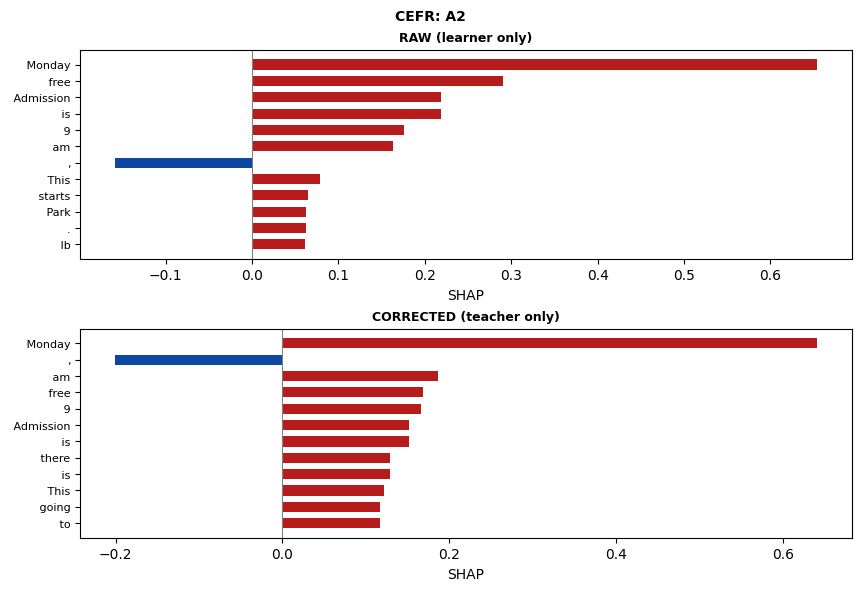

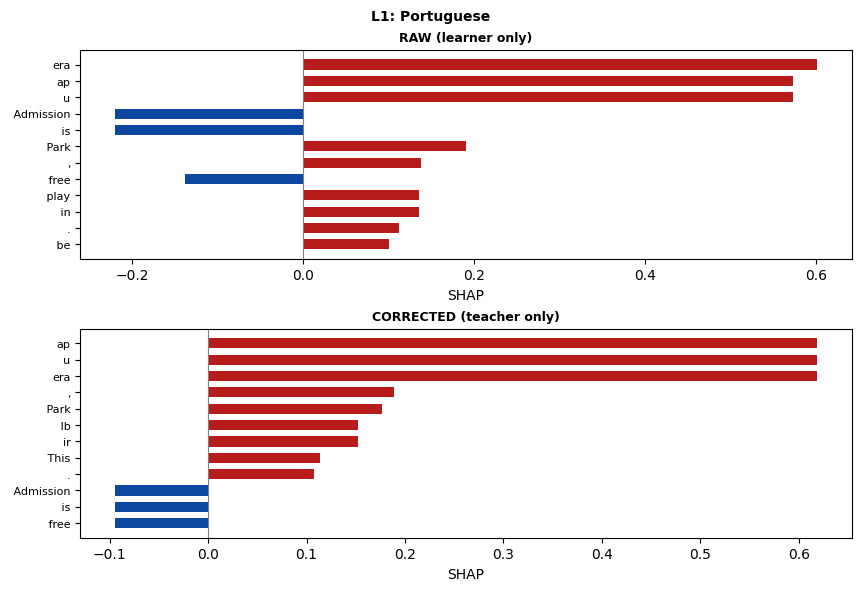

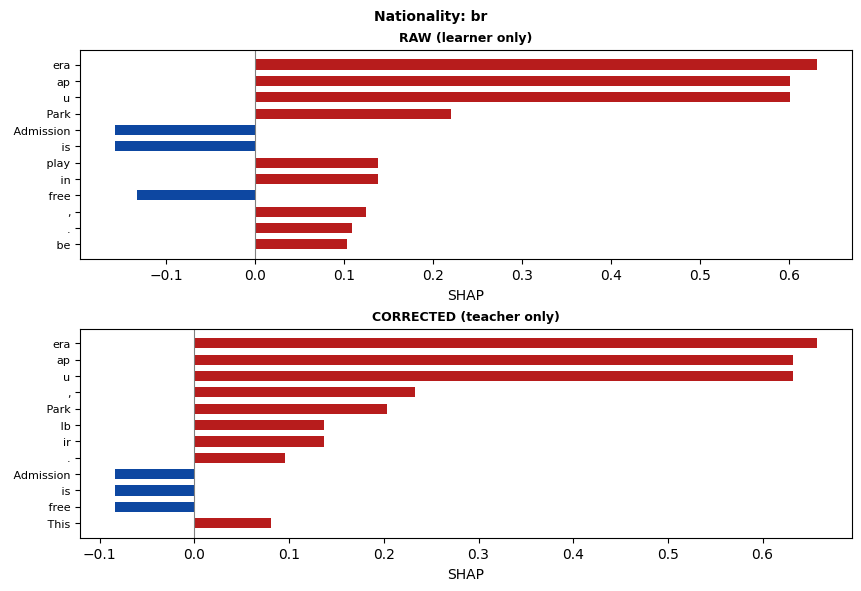


------------------------------------------------------------------------
  SHAP 2/5   idx 42,883   true CEFR A1
------------------------------------------------------------------------
  RAW:
    My Piano and Me I played piano when I was a young girl. My
    mother taught me for many years. I really enjoy it. Sometimes my
    mother held a concert for me at home and my colse friends came
    to my house. They always ask me to play new song. With piano I
    spent a wonderful childhood.
  COR:
    My piano and Me I played piano when I was a young girl. My
    mother taught me for many years. I really enjoy it. sometimes my
    mother held a concert for me at home and my close friends came
    to my house. They always ask me to play new song. With piano I
    spent a wonderful childhood.


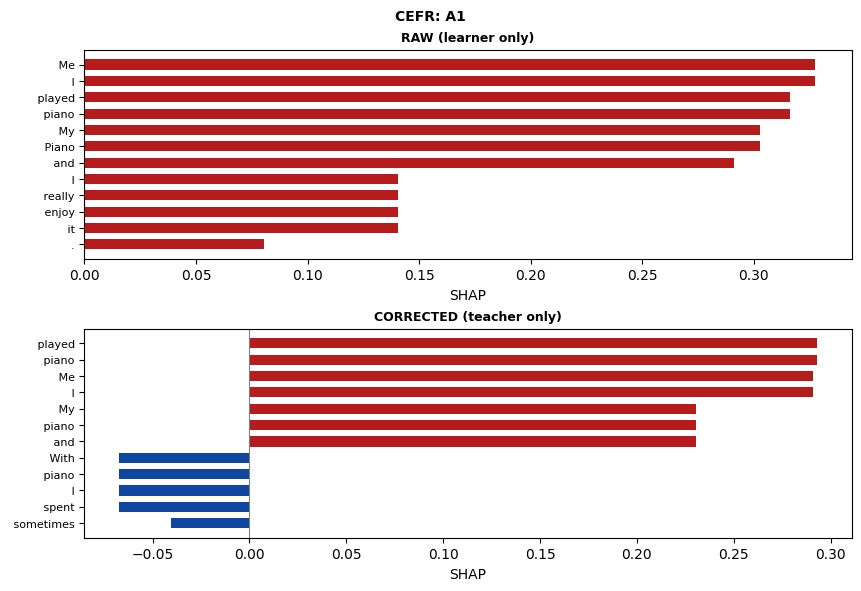

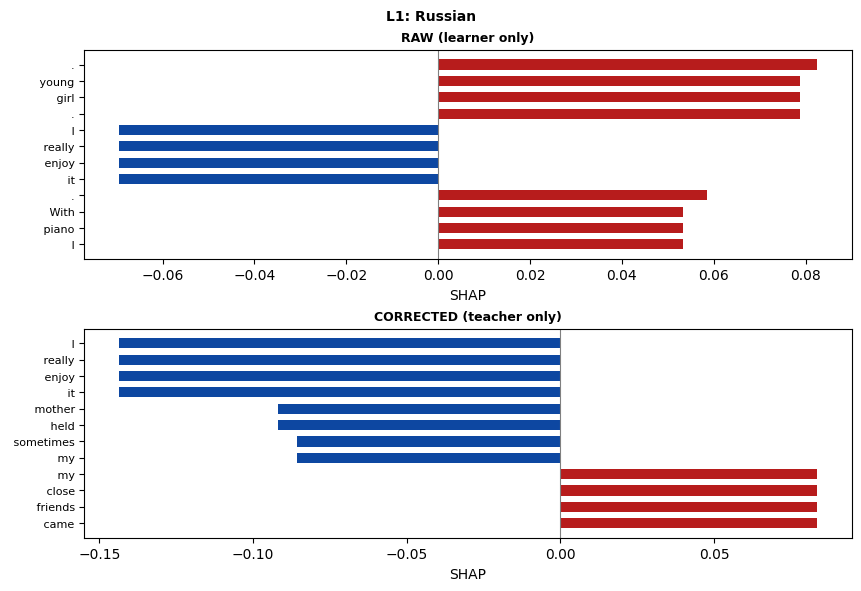

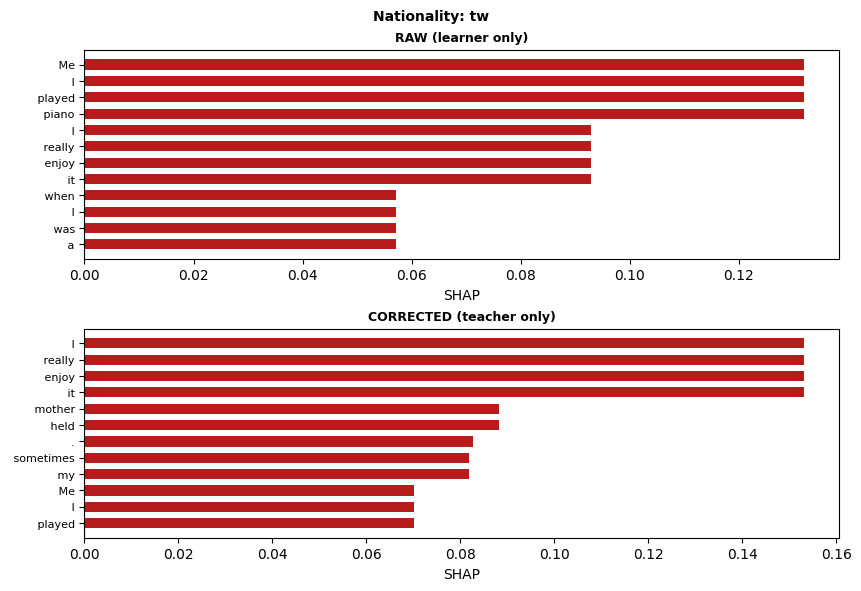


------------------------------------------------------------------------
  SHAP 3/5   idx 50,626   true CEFR B1
------------------------------------------------------------------------
  RAW:
    Hi Brother I'm really happy to write to you. I have many dreams
    in my life, but now It's being too hard to work at the bank, but
    I'm enjoying. I'm taking English classes, then soon I will
    travel to Canada to improve my skills. Next year I want to be an
    English teacher. I always wanted to be a teacher. Now I have the
    oportunity in front of me. I want to see you soon, maybe next
    month I will travel to So Paulo. Love Alex
  COR:
    Hi Brother I'm really happy to write to you. I have many dreams
    in my life, but now It's being too hard to work at the bank, but
    I'm enjoying. I'm taking English classes, then soon I will
    travel to Canada to improve my skills. Next year I want to be an
    English teacher. I always wanted to be a teacher. Now I have the
    opportu

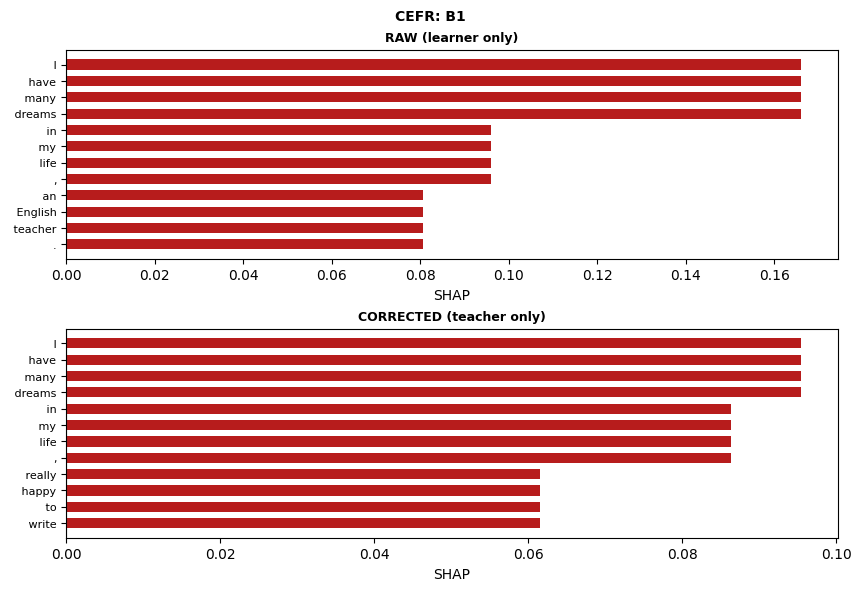

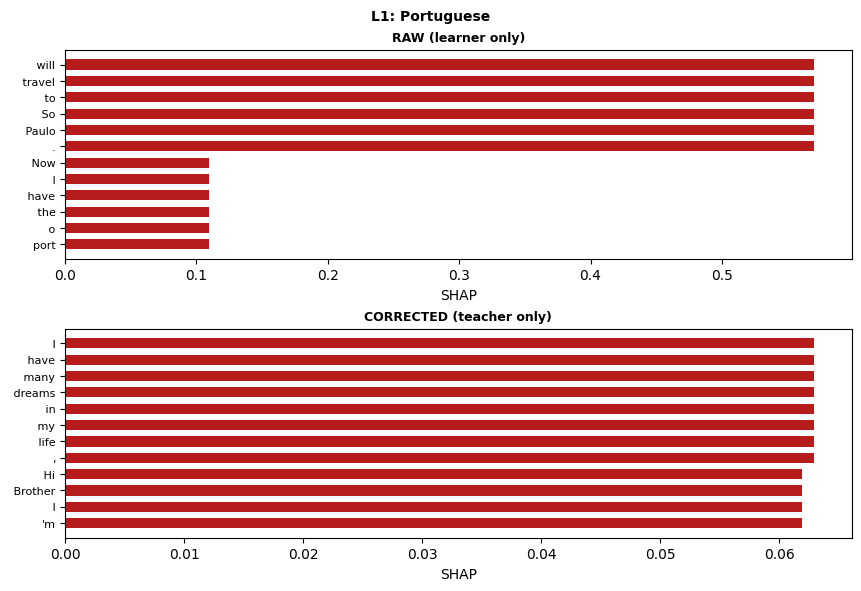

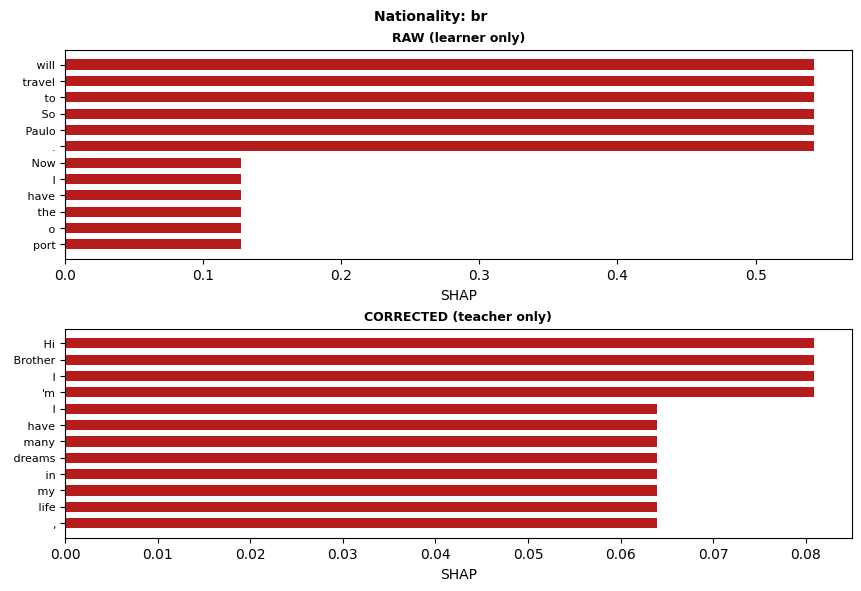


------------------------------------------------------------------------
  SHAP 4/5   idx 47,711   true CEFR B2
------------------------------------------------------------------------
  RAW:
    The French like to honour their good food with good presentation
    and good manners. If you've been invited as a guest to dinner,
    bring a hostess gift as flowers, a plant or chocolates. At the
    table in France, manners are important even while eating with
    your family. Always show up for dinner within ten minutes late.
    Give a call if you will be any longer than ten minutes late.
    Drinks won't be served until the last guests arrive.  Here are
    some helpful tips: Keep your hands on the table, this is very
    important. Eat with the fork in your left hand, and the knife in
    the right. Always wait for the host to say "bon apptit" before
    starting to eat. Most meals come with bread. If you don't have a
    side plate, putting the bread on the tablecloth beside your
   

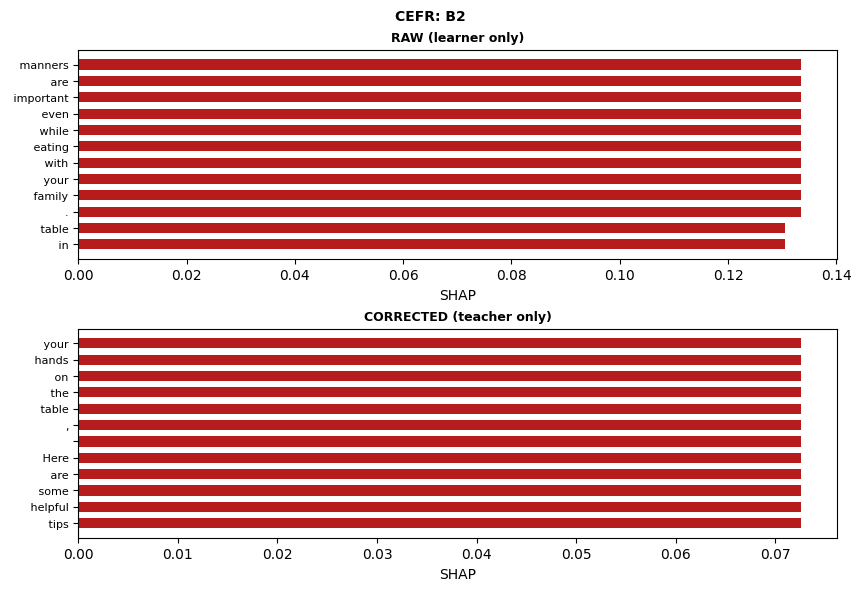

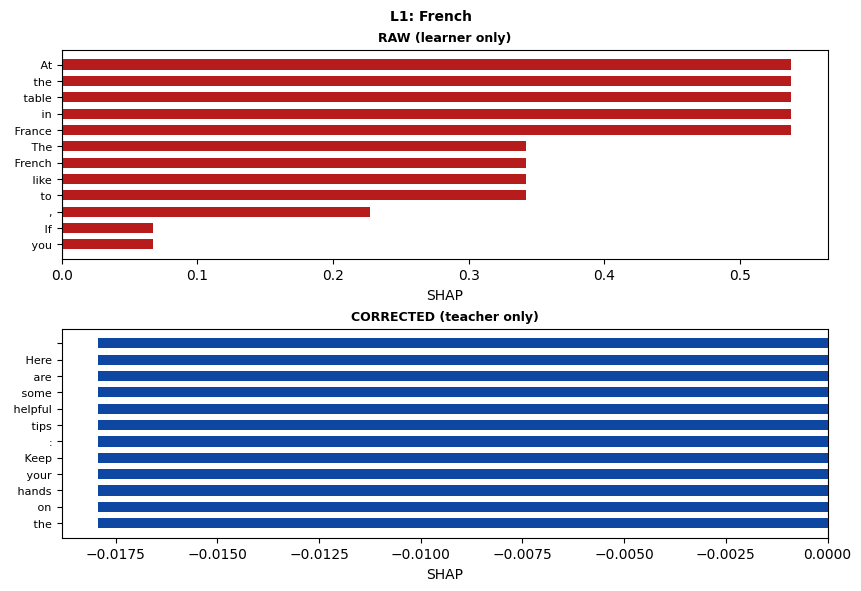

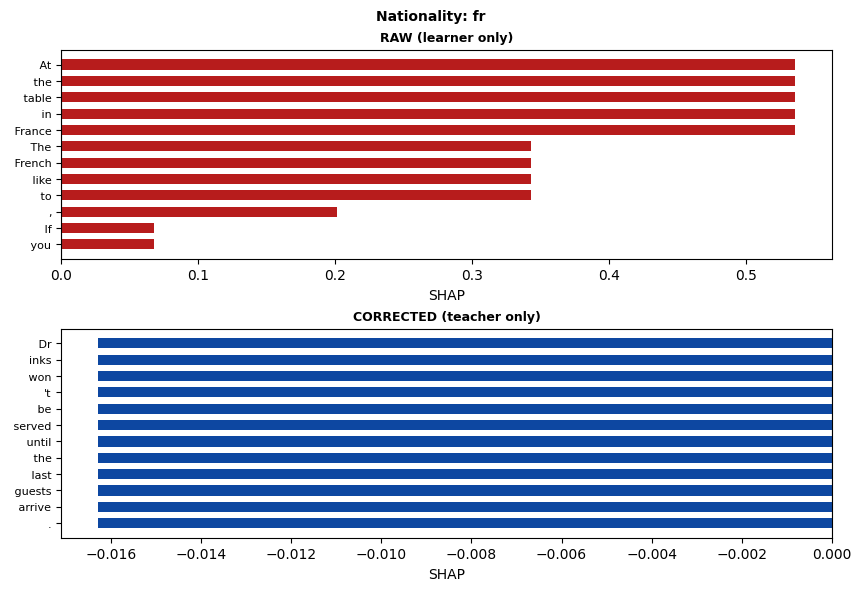


------------------------------------------------------------------------
  SHAP 5/5   idx 768   true CEFR C1
------------------------------------------------------------------------
  RAW:
    The Euro is approximately ten years old. At the beginning no one
    had liked the new currency. For ordinary citizen it was quite
    difficult to make out the benefits of the change. Suddenly
    everything was much more expensive than before. For example, a
    loaf of bread cost twice as much as before. The goverment had
    promised to all that the new currency would not cause a price
    rise. Mnay industries broke the promise an increased the prices
    of their products dramatically. Even today the German citizen do
    not have a lot of confidence in the new currency. We all know
    that the introduction of the Euro right and inportant. Only by
    the Euro Europe is competitive and can hold its own against the
    economic forces of China and America. Probably, we need many
    decate

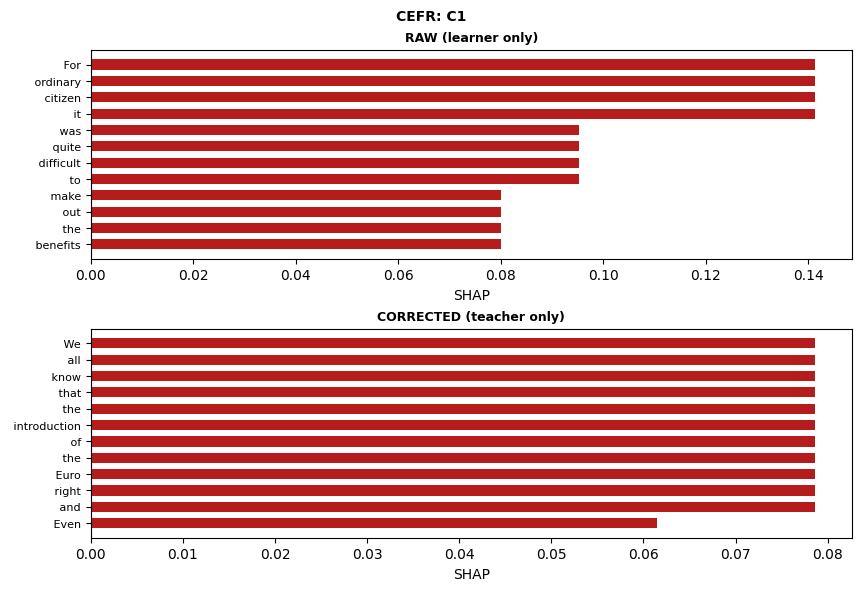

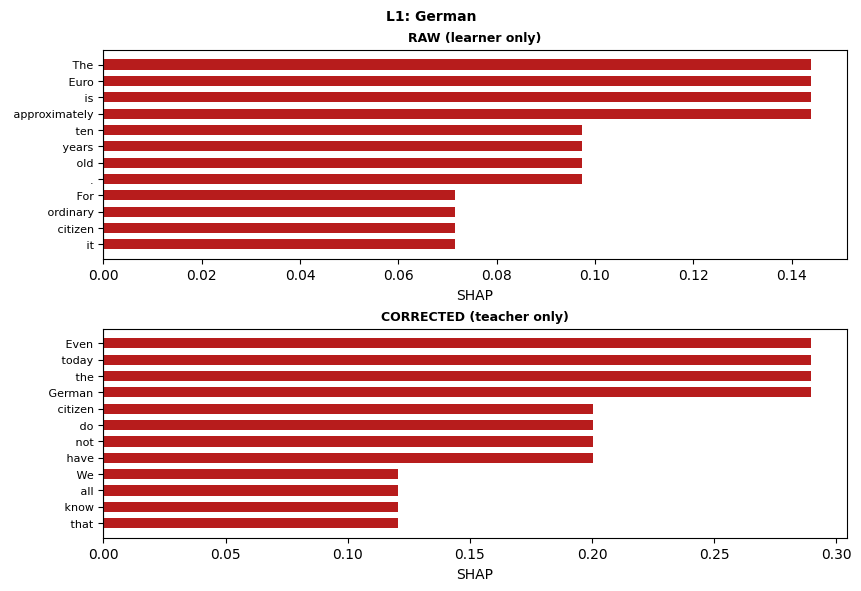

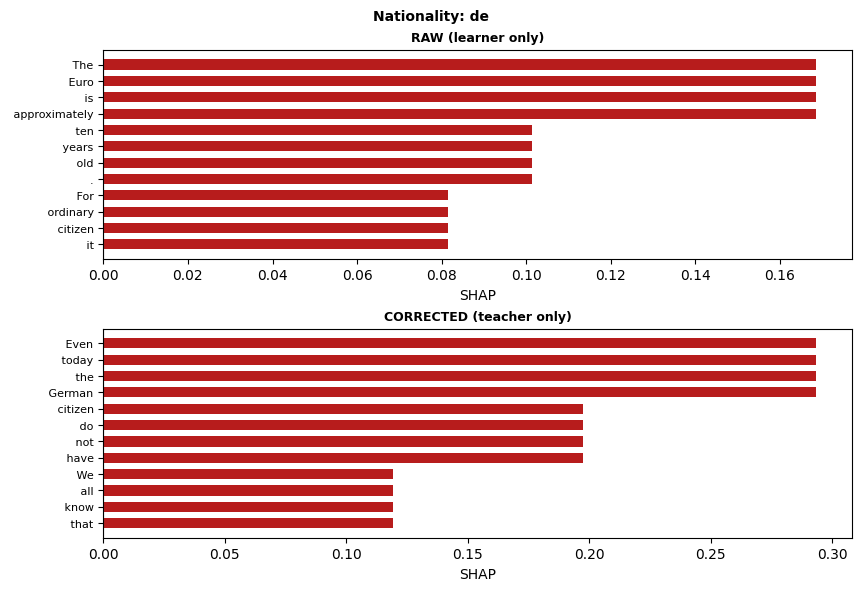

In [37]:
# Cell 13 — SHAP (few short examples only; run cell 12 first)

import textwrap

import matplotlib.pyplot as plt
import numpy as np
import shap

if "demo_test_examples" not in globals():
    raise RuntimeError("Run cell 12 first.")

MAXLEN = 128
TOP_TOKENS = 12
W = 72

SHAP_HEADS = ("cefr", "l1", "nat")

HEAD_INFO = [
    ("cefr", cefr_encoder, "CEFR"),
    ("l1", l1_encoder, "L1"),
    ("nat", nat_encoder, "Nationality"),
]

rows = globals().get("shap_demo_examples")
if not rows:
    rows = demo_test_examples[: min(3, len(demo_test_examples))]


def wrap_lines(s, w=64):
    t = str(s).replace("\n", " ").strip()
    return textwrap.wrap(t, width=w, break_long_words=True, break_on_hyphens=True)


def logits_head(texts, head_key):
    enc = tokenizer(
        list(texts),
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=MAXLEN,
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        return multitask_model(**enc)[head_key].cpu().numpy()


def raw_corr_token_indices(dual_text):
    """Split token indices by *character offsets* in the original dual string.

    - RAW: token ends before the separator starts (learner essay only).
    - CORRECTED: token starts at/after corrected body (teacher essay only).
    - Anything overlapping ` [CORRECTED] ` (incl. the marker token) is omitted from both.
    """
    sep = " [CORRECTED] "
    j = dual_text.find(sep)
    if j < 0:
        return None, None
    sep_start = j
    sep_end = j + len(sep)
    batch = tokenizer(
        [dual_text],
        truncation=True,
        max_length=MAXLEN,
        return_offsets_mapping=True,
        add_special_tokens=True,
    )
    pairs = batch["offset_mapping"][0]
    raw_i, corr_i = [], []
    for ti, span in enumerate(pairs):
        a, b = span[0], span[1]
        if a is None or b is None:
            continue
        a, b = int(a), int(b)
        if a == 0 and b == 0:
            continue
        if b <= sep_start:
            raw_i.append(ti)
        elif a >= sep_end:
            corr_i.append(ti)
    return raw_i, corr_i


def shap_1class(shap_row, class_i, n_tokens):
    V = np.asarray(shap_row.values, dtype=float)
    if V.ndim == 3:
        V = V[0]
    if V.ndim == 2:
        vec = V[:, class_i] if V.shape[1] > 1 else V[:, 0]
    else:
        vec = V.ravel()
    vec = vec[:n_tokens]
    if len(vec) < n_tokens:
        vec = np.pad(vec, (0, n_tokens - len(vec)))
    return vec


def plot_shap_dual(dual_text, shap_row, class_i, pred_name, task_title):
    enc = tokenizer(
        dual_text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=MAXLEN,
    )
    toks = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
    svals = shap_1class(shap_row, class_i, len(toks))
    raw_i, corr_i = raw_corr_token_indices(dual_text)
    if raw_i is None or not corr_i:
        n = len(toks) // 2
        raw_i, corr_i = list(range(0, n)), list(range(n, len(toks)))

    def skip_marker(label):
        s = label.replace("Ġ", "").strip()
        return "[CORRECTED]" in s or s == "[RAW]" or s.startswith("[RAW]")

    def panel(ax, idx_list, subtitle):
        bad = {"<s>", "</s>", "<pad>", "", "Ċ"}
        rows = []
        for i in idx_list:
            if i >= len(toks):
                break
            w = toks[i]
            if w in bad or not str(w).strip():
                continue
            lab = w.replace("Ġ", " ")
            if skip_marker(lab):
                continue
            rows.append((lab, float(svals[i])))
        rows.sort(key=lambda x: abs(x[1]), reverse=True)
        rows = rows[:TOP_TOKENS]
        if not rows:
            ax.set_title(subtitle)
            return
        lab, val = zip(*rows)
        y = np.arange(len(lab))
        ax.barh(y, val, height=0.62, color=["#b71c1c" if v >= 0 else "#0d47a1" for v in val])
        ax.set_yticks(y)
        ax.set_yticklabels(lab, fontsize=8)
        ax.axvline(0, color="gray", lw=0.8)
        ax.set_xlabel("SHAP")
        ax.set_title(subtitle, fontweight="bold", fontsize=9)
        ax.invert_yaxis()

    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8.5, 5.8), constrained_layout=True)
    panel(ax0, raw_i, "RAW (learner only)")
    panel(ax1, corr_i, "CORRECTED (teacher only)")
    fig.suptitle(f"{task_title}: {pred_name}", fontweight="bold", fontsize=10)
    plt.show()


explainers = {}
for h in SHAP_HEADS:

    def make_predictor(hk=h):
        return lambda texts: logits_head(texts, hk)

    explainers[h] = shap.Explainer(make_predictor(), tokenizer)

print()
print("=" * W)
print(f"  SHAP  ·  {len(rows)} essay(s)  ·  {len(SHAP_HEADS)} head(s) each  ·  top {TOP_TOKENS} tokens per panel")
print("=" * W)

for n, ex in enumerate(rows, start=1):
    print()
    print("-" * W)
    print(f"  SHAP {n}/{len(rows)}   idx {ex['idx']:,}   true CEFR {ex['true_cefr']}")
    print("-" * W)
    print("  RAW:")
    for ln in wrap_lines(ex["text"]):
        print("   ", ln)
    print("  COR:")
    for ln in wrap_lines(ex["text_corrected"]):
        print("   ", ln)

    dual = ex["dual_text"]
    batch = tokenizer([dual], return_tensors="pt", truncation=True, padding="max_length", max_length=MAXLEN)
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        out = multitask_model(**batch)

    last_shap = None
    for head_key, encoder, title in HEAD_INFO:
        if head_key not in SHAP_HEADS:
            continue
        pred_i = int(out[head_key].argmax(-1).item())
        pred_lbl = encoder.inverse_transform([pred_i])[0]
        last_shap = explainers[head_key]([dual])[0]
        plot_shap_dual(dual, last_shap, pred_i, pred_lbl, title)

    if globals().get("SHOW_SHAP_HTML", False) and last_shap is not None:
        shap.plots.text(last_shap)
